In [3]:
# --- Loading Data using kagglehub ---
# This cell automatically detects the downloaded CSV file and loads it into a DataFrame.

import kagglehub
import pandas as pd
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("atharvasoundankar/global-housing-market-analysis-2015-2024")
print("Path to dataset files:", path)

# List files in the directory to find the CSV name
files = os.listdir(path)
print("Files found:", files)

# Find the first CSV file in the directory
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# Load the dataset
df_housing = pd.read_csv(full_path)

# Quick check of the data
print(f"\nSuccessfully loaded: {csv_file}")
display(df_housing.head())


100%|██████████| 17.9k/17.9k [00:00<00:00, 10.8MB/s]

Extracting files...
Path to dataset files: C:\Users\Emails and Social\.cache\kagglehub\datasets\atharvasoundankar\global-housing-market-analysis-2015-2024\versions\1
Files found: ['global_housing_market_extended.csv']



Successfully loaded: global_housing_market_extended.csv


,Country,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
0,USA,2015,117.454012,116.550001,9.587945,4.493292,1.514121,-0.752044,-0.796707,85.985284,118.089201
1,USA,2016,150.807258,51.440915,11.729189,5.662213,1.880204,-0.545400,-0.358084,69.127267,111.980515
2,USA,2017,123.194502,70.386040,8.506676,2.197469,2.398940,0.930895,0.596245,83.555279,85.973903
3,USA,2018,131.423444,91.469020,3.418054,4.537724,1.608407,-1.479587,2.321099,88.968961,134.671788
4,USA,2019,110.461377,56.837048,9.158097,3.700762,1.293249,1.961415,-0.879640,87.279612,90.702399


In [4]:
# --- Basic Exploratory Data Analysis (EDA) ---
# This cell provides summary statistics and checks for data integrity.

# 1. Check the dimensions of the dataset
print(f"Dataset shape: {df_housing.shape}")

# 2. Get summary statistics for numerical columns
# This helps identify the scale and potential outliers in prices and rates.
print("\n--- Summary Statistics ---")
display(df_housing.describe())

# 3. Check for missing values (crucial for Data Cleaning)
print("\n--- Missing Values ---")
print(df_housing.isnull().sum())

# 4. Check unique countries to understand the scope
unique_countries = df_housing['Country'].unique()
print(f"\nNumber of unique countries: {len(unique_countries)}")
print(f"Countries included: {', '.join(unique_countries)}")

# 5. Check the time range
year_min = df_housing['Year'].min()
year_max = df_housing['Year'].max()
print(f"\nAnalysis Period: {year_min} - {year_max}")


Dataset shape: (200, 11)

--- Summary Statistics ---


,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2019.500000,130.381022,83.048370,7.237768,4.150621,3.649756,2.133722,0.722806,74.769891,111.204257
std,2.879489,28.752229,21.439858,2.576085,1.380222,1.881938,2.413270,1.035691,8.734246,24.309473
min,2015.000000,80.552212,50.354311,3.041688,1.537814,0.532110,-1.921833,-0.961391,60.172760,70.968678
25%,2017.000000,104.142562,60.466671,5.034207,3.045278,1.939199,-0.095628,-0.183320,66.923842,90.182198
50%,2019.500000,129.193653,83.721711,7.375697,4.329643,3.664625,2.307548,0.722372,75.100060,110.593807
75%,2022.000000,157.127098,100.604665,9.276196,5.217706,5.261720,4.272776,1.621317,82.677430,133.780445
max,2024.000000,179.971767,119.855388,11.879671,6.485623,6.912349,5.958931,2.497948,89.788944,149.735748



--- Missing Values ---
Country                  0
Year                     0
House Price Index        0
Rent Index               0
Affordability Ratio      0
Mortgage Rate (%)        0
Inflation Rate (%)       0
GDP Growth (%)           0
Population Growth (%)    0
Urbanization Rate (%)    0
Construction Index       0
dtype: int64

Number of unique countries: 20
Countries included: USA, Canada, UK, Germany, France, Italy, Spain, Australia, India, China, Japan, Brazil, South Korea, Mexico, South Africa, Russia, Netherlands, Sweden, Switzerland, UAE

Analysis Period: 2015 - 2024


## Exploratory Data Analysis (EDA)
In this section, we analyze the distribution of the **House Price Index** and examine how the housing market varies across different countries. 

Key objectives:
1.  Visualize the distribution of house prices.
2.  Identify the Top 10 countries with the highest average House Price Index.
3.  Check for potential outliers in the economic indicators.


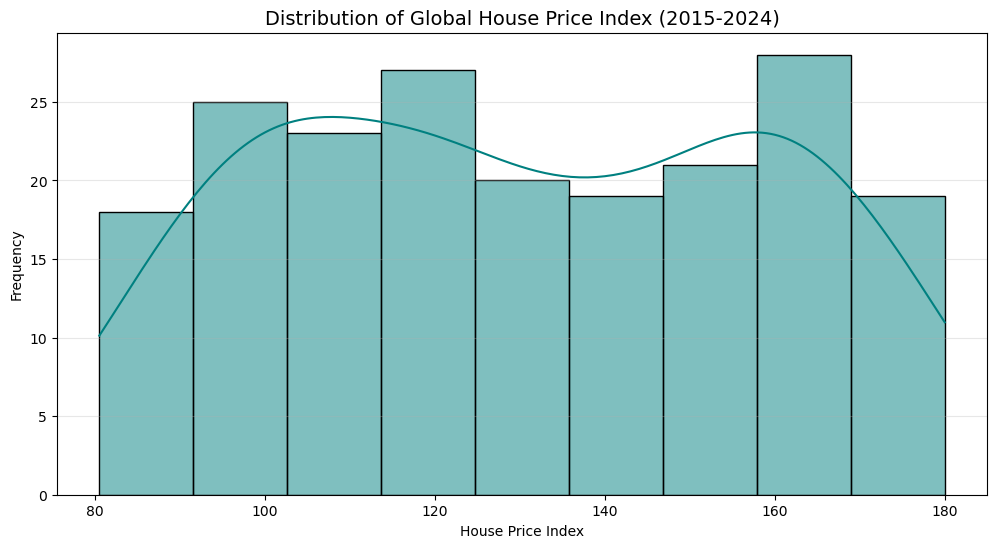

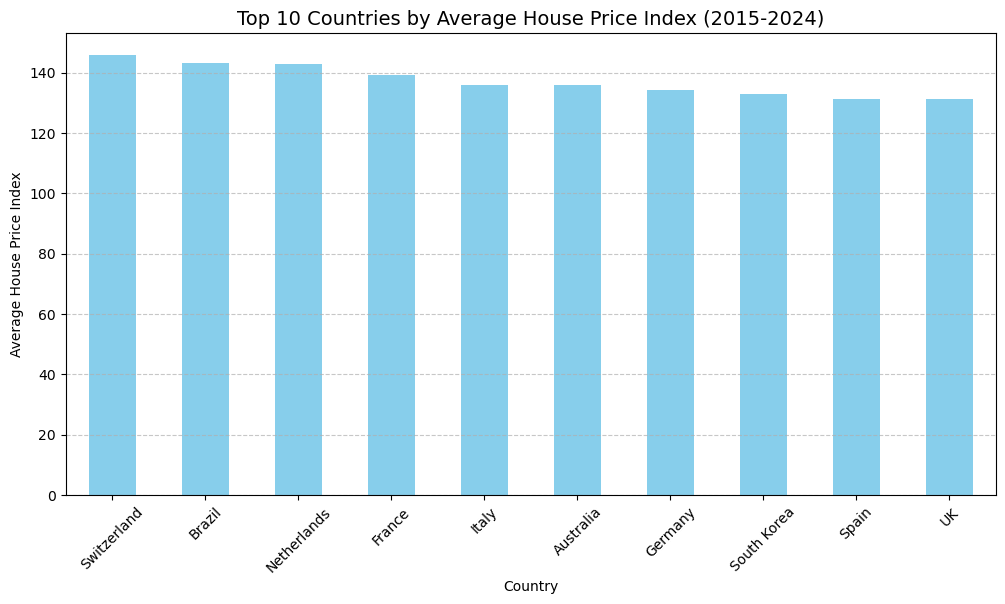

Descriptive Statistics for Top 10 Countries:
Country
Switzerland    145.830268
Brazil         143.080085
Netherlands    142.847068
France         139.344904
Italy          135.926407
Australia      135.752524
Germany        134.204203
South Korea    132.735159
Spain          131.289414
UK             131.094884
Name: House Price Index, dtype: float64


In [6]:
# --- Exploratory Data Analysis: Distributions and Rankings ---

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution of House Price Index
plt.figure(figsize=(12, 6))
sns.histplot(df_housing['House Price Index'], kde=True, color='teal')
plt.title('Distribution of Global House Price Index (2015-2024)', fontsize=14)
plt.xlabel('House Price Index')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Identifying Top 10 Countries by Average House Price Index
top_countries = df_housing.groupby('Country')['House Price Index'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Average House Price Index (2015-2024)', fontsize=14)
plt.ylabel('Average House Price Index')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Descriptive Statistics for the Top 10
print("Descriptive Statistics for Top 10 Countries:")
print(top_countries)
